# Credit Card Fraud Detection — Model Building

This notebook builds and evaluates machine learning models for credit card fraud detection.

The cleaned dataset from the data cleaning notebook is loaded from:

`data/creditcard_cleaned.csv`

Because the dataset is highly imbalanced, accuracy alone is not suitable for model evaluation. Therefore, this notebook focuses on metrics such as Precision, Recall, F1-score, ROC-AUC, and confusion matrix.# Credit Card Fraud Detection — Model Building

Train and compare 7 classification models on the cleaned credit card dataset. The dataset has extreme class imbalance (~0.97% fraud), so we apply `class_weight='balanced'` wherever supported. **Recall, F1, and Precision-Recall AUC** are the primary metrics — accuracy is deliberately de-emphasised throughout this notebook.

## 1. Imports and Load Cleaned Dataset

We import the required libraries, helper functions, and load the cleaned dataset created during the data cleaning stage.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
# Add current project folder to path
sys.path.append(".")

from utils import (
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curves,
    compare_models
)

# Chart settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load cleaned dataset
df = pd.read_csv("data/creditcard_cleaned.csv")

print(f"Cleaned dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

df.head()

Cleaned dataset loaded: 283,726 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.995290,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.774718,0
1,-0.995290,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.268530,0
2,-0.995279,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.959811,0
3,-0.995279,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.411487,0
4,-0.995267,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.667362,0


In [28]:
print("Modeling Dataset Check")
print("----------------------")
print(f"Rows           : {df.shape[0]:,}")
print(f"Columns        : {df.shape[1]}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")

print("\nClass Distribution")
print("------------------")
print(df["Class"].value_counts())

print(f"\nFraud rate: {df['Class'].mean() * 100:.4f}%")

Modeling Dataset Check
----------------------
Rows           : 283,726
Columns        : 31
Missing values : 0
Duplicate rows : 0

Class Distribution
------------------
Class
0    283253
1       473
Name: count, dtype: int64

Fraud rate: 0.1667%


### Dataset Verification

The cleaned dataset contains 283,726 rows and 31 columns. There are no missing values and no duplicate rows.

The target variable is still highly imbalanced, with only 473 fraud transactions after removing duplicates. Therefore, the model evaluation stage must focus on fraud detection metrics such as Precision, Recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy alone.

## 2. Train / Test Split

We use an 80/20 stratified split so that the fraud rate in both training and testing sets is similar to the overall dataset.

The cleaned dataset already has duplicate rows removed, and the `Amount` and `Time` columns have already been scaled using RobustScaler. Therefore, no additional StandardScaler is needed.

In [29]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature and target split completed.")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nTarget distribution:")
print(y.value_counts())

print(f"\nFraud rate: {y.mean() * 100:.4f}%")


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain-test split completed.")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean() * 100:.4f}%")
print(f"Test fraud rate : {y_test.mean() * 100:.4f}%")

Feature and target split completed.
X shape: (283726, 30)
y shape: (283726,)

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud rate: 0.1667%

Train-test split completed.
Train: (226980, 30) | Test: (56746, 30)
Train fraud rate: 0.1665%
Test fraud rate : 0.1674%


In [30]:
train_distribution = pd.DataFrame({
    "Count": y_train.value_counts(),
    "Percentage": (y_train.value_counts(normalize=True) * 100).round(4)
})

test_distribution = pd.DataFrame({
    "Count": y_test.value_counts(),
    "Percentage": (y_test.value_counts(normalize=True) * 100).round(4)
})

train_distribution.index = ["Legitimate", "Fraud"]
test_distribution.index = ["Legitimate", "Fraud"]

print("Training Set Class Distribution")
display(train_distribution)

print("Testing Set Class Distribution")
display(test_distribution)

Training Set Class Distribution


,Count,Percentage
Legitimate,226602,99.8335
Fraud,378,0.1665


Testing Set Class Distribution


,Count,Percentage
Legitimate,56651,99.8326
Fraud,95,0.1674


### Train-Test Split Interpretation

The dataset was split into 80% training data and 20% testing data.

Stratified splitting was used because the dataset is highly imbalanced. This keeps the fraud percentage similar in both training and testing sets.

The training set contains around 378 fraud transactions, while the testing set contains around 95 fraud transactions. This allows the model to be trained and evaluated on both legitimate and fraudulent transactions.

## 3. Model 1 — Logistic Regression

Logistic Regression is used as the first baseline model.

Because the dataset is highly imbalanced, `class_weight="balanced"` is used. This gives more importance to the minority class, which is the fraud class.

The model is evaluated using Precision, Recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy alone.


  Logistic Regression
  Accuracy    : 0.9753
  Precision   : 0.0564
  Recall      : 0.8737
  F1          : 0.1059
  ROC-AUC     : 0.9657


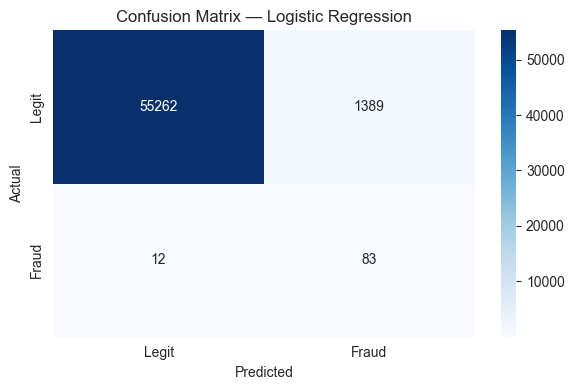

In [31]:
# Model 1: Logistic Regression

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight="balanced"
)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluate model
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)

# Confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_lr,
    "Logistic Regression"
)

plt.show()

In [32]:
print("Classification Report — Logistic Regression")
print("-------------------------------------------")
print(classification_report(y_test, y_pred_lr, target_names=["Legitimate", "Fraud"]))

Classification Report — Logistic Regression
-------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



### Logistic Regression Interpretation

Logistic Regression was used as the baseline model.

Because `class_weight="balanced"` was applied, the model gives more importance to fraud transactions during training. This helps improve fraud detection recall.

For fraud detection, Recall is very important because it shows how many actual fraud transactions were correctly detected. However, Precision is also important because low precision means many legitimate transactions are wrongly predicted as fraud.

The confusion matrix helps identify:

- True negatives: legitimate transactions correctly predicted as legitimate
- False positives: legitimate transactions incorrectly predicted as fraud
- False negatives: fraud transactions missed by the model
- True positives: fraud transactions correctly detected

Since this is a fraud detection problem, the model should reduce false negatives as much as possible while keeping false positives at a reasonable level.

## 4. Model 2 — Decision Tree

A Decision Tree model is trained as the second model.

Decision Trees can capture non-linear patterns in the data, but they can also overfit. Therefore, `max_depth=8` is used to limit the tree depth.

Because the dataset is highly imbalanced, `class_weight="balanced"` is used to give more importance to fraud transactions.


  Decision Tree
  Accuracy    : 0.9915
  Precision   : 0.1405
  Recall      : 0.8000
  F1          : 0.2390
  ROC-AUC     : 0.9074


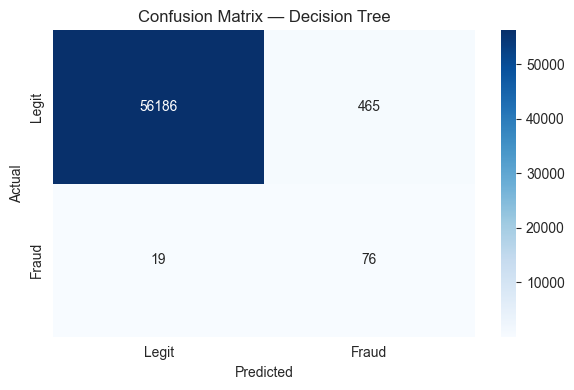

In [33]:
# Model 2: Decision Tree

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=8
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate model
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt,
    y_prob_dt
)

# Confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_dt,
    "Decision Tree"
)

plt.show()

In [34]:
print("Classification Report — Decision Tree")
print("-------------------------------------")
print(classification_report(y_test, y_pred_dt, target_names=["Legitimate", "Fraud"]))

Classification Report — Decision Tree
-------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56651
       Fraud       0.14      0.80      0.24        95

    accuracy                           0.99     56746
   macro avg       0.57      0.90      0.62     56746
weighted avg       1.00      0.99      0.99     56746



### Decision Tree Interpretation

The Decision Tree model can learn non-linear relationships in the dataset.

Using `class_weight="balanced"` helps the model pay more attention to fraud transactions. The `max_depth=8` parameter limits the tree depth and helps reduce overfitting.

In fraud detection, the most important focus is not only accuracy. We need to check Recall, Precision, F1-score, ROC-AUC, and the confusion matrix.

A high Recall means the model detects more actual fraud cases. However, if Precision is low, the model may incorrectly mark many legitimate transactions as fraud.

## 5. Model 3 — Random Forest

Random Forest is used as the third model.

Random Forest combines many decision trees to improve performance and reduce overfitting compared to a single Decision Tree.

Because the dataset is highly imbalanced, `class_weight="balanced"` is used to give more importance to fraud transactions.


  Random Forest
  Accuracy    : 0.9995
  Precision   : 0.9710
  Recall      : 0.7053
  F1          : 0.8171
  ROC-AUC     : 0.9246


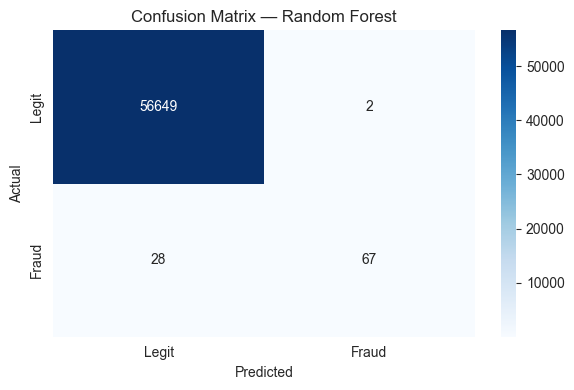

In [35]:
# Model 3: Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate model
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

# Confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_rf,
    "Random Forest"
)

plt.show()

In [36]:
print("Classification Report — Random Forest")
print("-------------------------------------")
print(classification_report(y_test, y_pred_rf, target_names=["Legitimate", "Fraud"]))

Classification Report — Random Forest
-------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



### Random Forest Interpretation

Random Forest combines multiple decision trees to make more stable predictions than a single Decision Tree.

It usually improves Precision because it reduces random errors from individual trees. However, in highly imbalanced fraud detection problems, the model may still miss some fraud cases if the minority class is very small.

For this project, the confusion matrix is very important. We need to check how many fraud transactions were correctly detected and how many were missed.

A good fraud detection model should have strong Recall, good Precision, and a balanced F1-score.

## 6. Model 4 — Naive Bayes

Gaussian Naive Bayes is used as the fourth model.

Naive Bayes is simple and fast. It assumes that features are independent from each other. Since the dataset contains PCA-transformed features, this model can be used as a lightweight comparison model.

Naive Bayes does not support `class_weight="balanced"`, so it may not handle class imbalance as well as Logistic Regression, Decision Tree, or Random Forest.


  Naive Bayes
  Accuracy    : 0.9775
  Precision   : 0.0578
  Recall      : 0.8105
  F1          : 0.1078
  ROC-AUC     : 0.9488


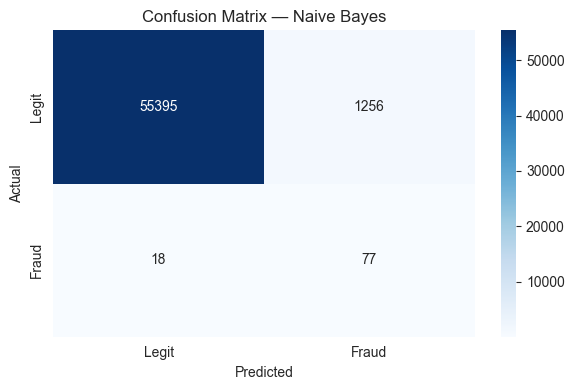

In [37]:
# Model 4: Naive Bayes

nb_model = GaussianNB()

# Train model
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

# Evaluate model
nb_results = evaluate_model(
    "Naive Bayes",
    y_test,
    y_pred_nb,
    y_prob_nb
)

# Confusion matrix
plot_confusion_matrix(
    y_test,
    y_pred_nb,
    "Naive Bayes"
)

plt.show()

In [38]:
print("Classification Report — Naive Bayes")
print("-----------------------------------")
print(classification_report(y_test, y_pred_nb, target_names=["Legitimate", "Fraud"]))

Classification Report — Naive Bayes
-----------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.06      0.81      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.89      0.55     56746
weighted avg       1.00      0.98      0.99     56746



### Naive Bayes Interpretation

Naive Bayes is a simple and fast classification model.

It can be useful as a comparison model because it trains quickly and gives probability outputs. However, it assumes that features are independent, which may not always be true in real-world data.

Naive Bayes also does not support class weighting, so it may not perform as well as models that handle class imbalance directly.

For this project, Naive Bayes should be compared with Logistic Regression, Decision Tree, and Random Forest using Precision, Recall, F1-score, ROC-AUC, and confusion matrix.

## 7. Model Comparison

We collect all model results into a single comparison table. Since this is a highly imbalanced fraud detection problem, we should not select the best model using accuracy alone.

The most important metrics are Precision, Recall, F1-score, ROC-AUC, and the confusion matrix.

In [39]:
# Collect model results

results = [
    lr_results,
    dt_results,
    rf_results,
    nb_results
]

df_results = compare_models(results)

print("Model Comparison Results")
print("------------------------")
display(df_results.round(4))

Model Comparison Results
------------------------


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.9995,0.9710,0.7053,0.8171,0.9246
1,Decision Tree,0.9915,0.1405,0.8000,0.2390,0.9074
2,Naive Bayes,0.9775,0.0578,0.8105,0.1078,0.9488
3,Logistic Regression,0.9753,0.0564,0.8737,0.1059,0.9657


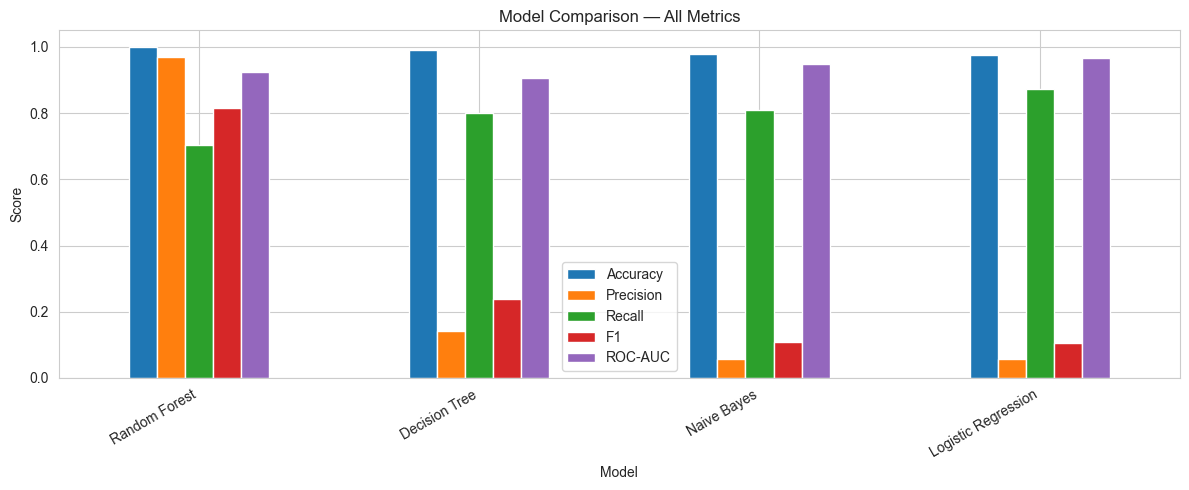

In [40]:
# Plot model comparison

df_plot = df_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]

ax = df_plot.plot(
    kind="bar",
    figsize=(12, 5)
)

ax.set_title("Model Comparison — All Metrics")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

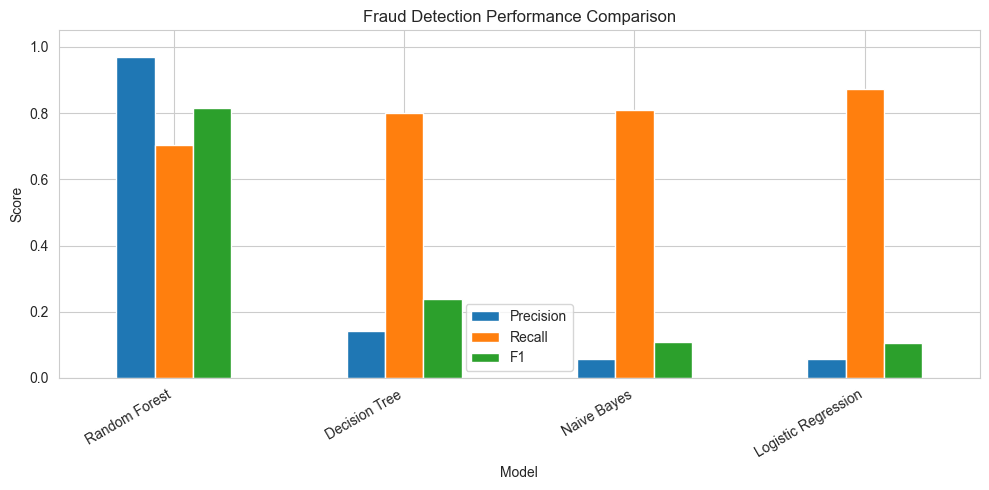

In [41]:
# Focused comparison: Precision, Recall, and F1-score

df_focus = df_results.set_index("Model")[["Precision", "Recall", "F1"]]

ax = df_focus.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Fraud Detection Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Model Comparison Interpretation

The models are compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Accuracy is not enough for this project because the dataset is highly imbalanced. A model can achieve very high accuracy by predicting most transactions as legitimate, but still fail to detect fraud.

Recall shows how many actual fraud cases were correctly detected. Precision shows how many predicted fraud cases were actually fraud. F1-score balances Precision and Recall.

For this fraud detection project, the best model should have a strong F1-score while also maintaining good Recall and Precision.

## 8. Cross-Validation

Cross-validation gives a more reliable estimate of model performance than a single train-test split.

Because the dataset is large, 3-fold cross-validation is used to reduce execution time. The scoring metric is F1-score because this is an imbalanced fraud detection problem.

In [42]:
from sklearn.model_selection import cross_val_score

# Models for cross-validation
cv_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=8
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "Naive Bayes": GaussianNB()
}

cv_results = []

for name, model in cv_models.items():
    print(f"\nRunning cross-validation for {name}...")
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std(),
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2]
    })
    
    print(f"F1 Scores: {scores.round(4)}")
    print(f"Mean F1 : {scores.mean():.4f}")
    print(f"Std F1  : {scores.std():.4f}")

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df.round(4))


Running cross-validation for Logistic Regression...
F1 Scores: [0.1276 0.0944 0.113 ]
Mean F1 : 0.1117
Std F1  : 0.0136

Running cross-validation for Decision Tree...
F1 Scores: [0.303  0.2038 0.1766]
Mean F1 : 0.2278
Std F1  : 0.0543

Running cross-validation for Random Forest...
F1 Scores: [0.7909 0.8482 0.8755]
Mean F1 : 0.8382
Std F1  : 0.0353

Running cross-validation for Naive Bayes...
F1 Scores: [0.1086 0.1146 0.1124]
Mean F1 : 0.1118
Std F1  : 0.0025


,Model,CV F1 Mean,CV F1 Std,Fold 1,Fold 2,Fold 3
0,Logistic Regression,0.1117,0.0136,0.1276,0.0944,0.1130
1,Decision Tree,0.2278,0.0543,0.3030,0.2038,0.1766
2,Random Forest,0.8382,0.0353,0.7909,0.8482,0.8755
3,Naive Bayes,0.1118,0.0025,0.1086,0.1146,0.1124


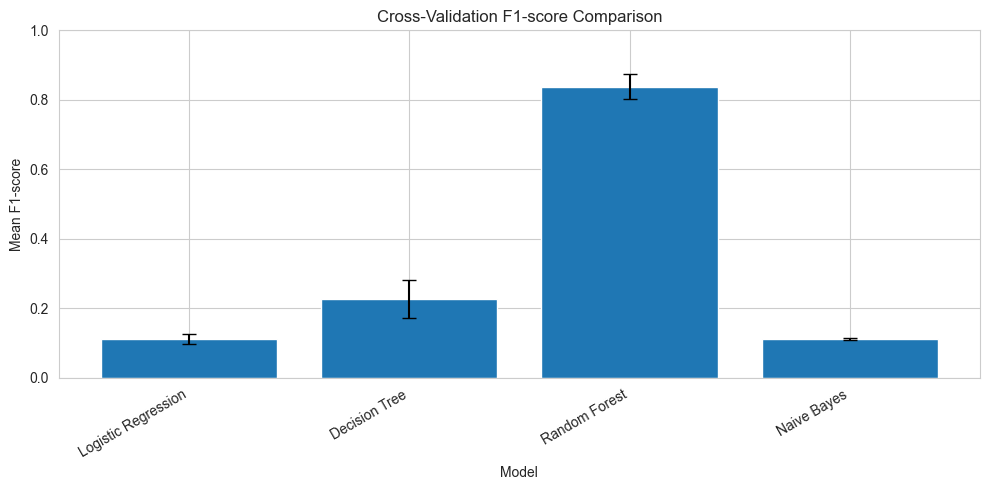

In [43]:
plt.figure(figsize=(10, 5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["CV F1 Mean"],
    yerr=cv_results_df["CV F1 Std"],
    capsize=5
)

plt.title("Cross-Validation F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Mean F1-score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Cross-Validation Interpretation

Cross-validation was used to check whether model performance is stable across different training folds.

The F1-score was used because the dataset is highly imbalanced. F1-score balances Precision and Recall, making it more useful than accuracy for fraud detection.

A model with a high mean F1-score and low standard deviation is more reliable. If the standard deviation is high, the model performance changes significantly across different folds.

The cross-validation results should be compared with the test set results before selecting the final best model.

## 9. ROC Curves and Precision-Recall Curves

ROC curves and Precision-Recall curves help compare model performance using predicted probabilities.

For highly imbalanced datasets, Precision-Recall curves are especially useful because they focus on the positive class, which is fraud in this project.

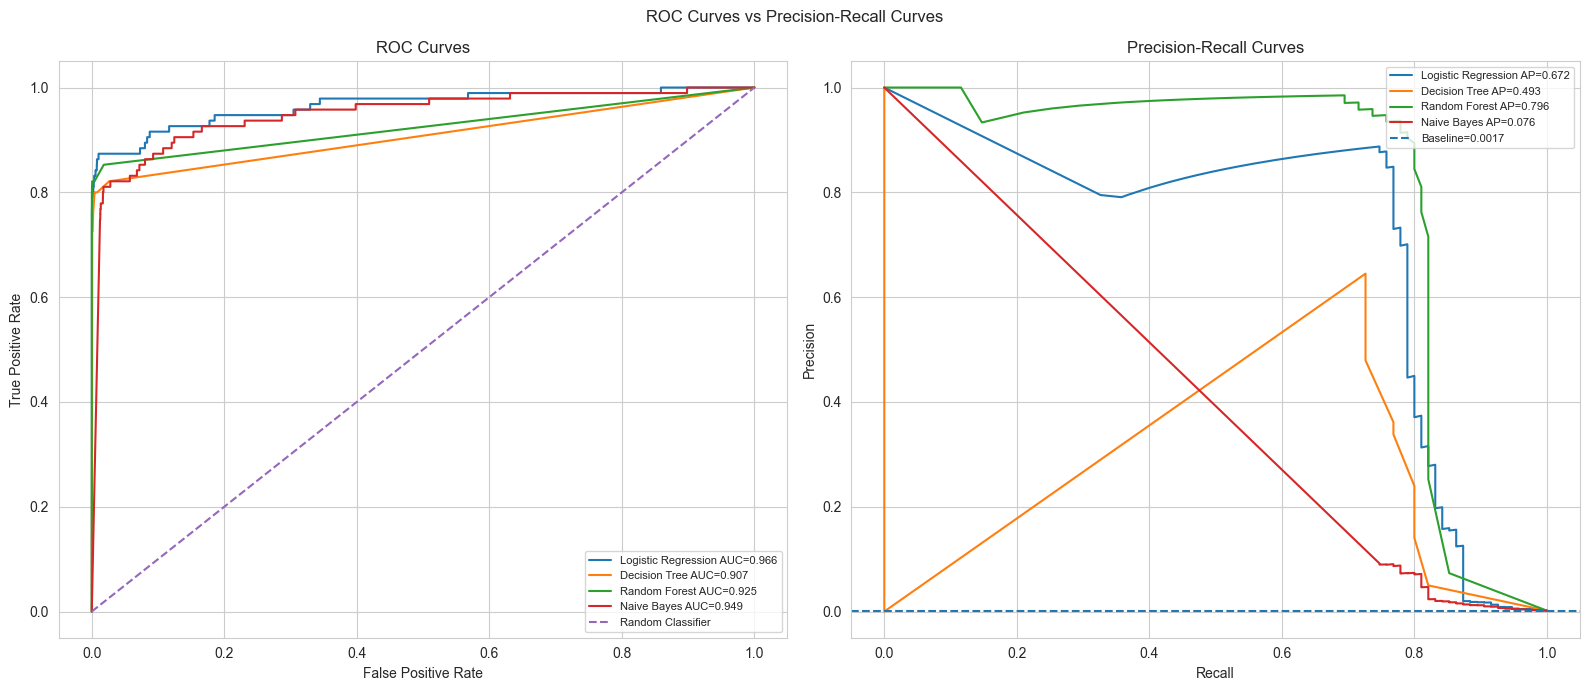

In [44]:
# Predicted probabilities from each model

model_probs = {
    "Logistic Regression": y_prob_lr,
    "Decision Tree": y_prob_dt,
    "Random Forest": y_prob_rf,
    "Naive Bayes": y_prob_nb
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC Curves
for name, prob in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc_value = auc(fpr, tpr)
    
    axes[0].plot(
        fpr,
        tpr,
        label=f"{name} AUC={roc_auc_value:.3f}"
    )

axes[0].plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(loc="lower right", fontsize=8)


# Precision-Recall Curves
for name, prob in model_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap_score = average_precision_score(y_test, prob)
    
    axes[1].plot(
        recall,
        precision,
        label=f"{name} AP={ap_score:.3f}"
    )

baseline_pr = y_test.mean()

axes[1].axhline(
    baseline_pr,
    linestyle="--",
    label=f"Baseline={baseline_pr:.4f}"
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(loc="upper right", fontsize=8)

plt.suptitle("ROC Curves vs Precision-Recall Curves")
plt.tight_layout()
plt.show()

### ROC and Precision-Recall Curve Interpretation

The ROC curve shows the relationship between the true positive rate and false positive rate. ROC-AUC is useful, but in highly imbalanced datasets it can sometimes look very high even when fraud detection is not strong.

The Precision-Recall curve is more important for this project because fraud is the minority class. It shows the trade-off between detecting fraud cases and avoiding false fraud alarms.

Average Precision measures the area under the Precision-Recall curve. A higher Average Precision score means the model performs better at identifying fraud transactions.

For this fraud detection project, the Precision-Recall curve and F1-score should be considered carefully when selecting the final best model.

## 10. Hyperparameter Tuning — Random Forest

Random Forest performed strongly in the baseline model comparison, so we tune selected hyperparameters to check whether performance can be improved.

A small parameter grid is used to keep runtime manageable. The tuning uses F1-score because the dataset is highly imbalanced and fraud detection requires a balance between Precision and Recall.

In [45]:
# Hyperparameter tuning for Random Forest

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Random Forest tuning completed.")
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Best CV F1-score: {grid_rf.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Random Forest tuning completed.
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV F1-score: 0.8487



  Random Forest Tuned
  Accuracy    : 0.9995
  Precision   : 0.9583
  Recall      : 0.7263
  F1          : 0.8263
  ROC-AUC     : 0.9285


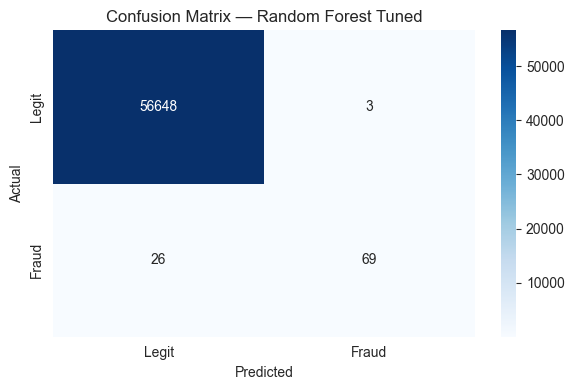

In [46]:
# Evaluate tuned Random Forest model

rf_tuned_model = grid_rf.best_estimator_

y_pred_rf_tuned = rf_tuned_model.predict(X_test)
y_prob_rf_tuned = rf_tuned_model.predict_proba(X_test)[:, 1]

rf_tuned_results = evaluate_model(
    "Random Forest Tuned",
    y_test,
    y_pred_rf_tuned,
    y_prob_rf_tuned
)

plot_confusion_matrix(
    y_test,
    y_pred_rf_tuned,
    "Random Forest Tuned"
)

plt.show()

### Hyperparameter Tuning Interpretation

Random Forest hyperparameter tuning was performed using GridSearchCV.

The tuning process tested different values for `n_estimators`, `max_depth`, and `min_samples_leaf`. The scoring metric was F1-score because this project is focused on fraud detection with an imbalanced dataset.

The tuned model should be compared with the original Random Forest model. If the tuned model improves F1-score, Precision, or Recall, it can be selected as the final model. If the improvement is very small, the simpler baseline Random Forest model may still be acceptable.

## 11. Feature Importance — Tuned Random Forest

Feature importance from the tuned Random Forest model helps identify which features contributed most to fraud detection.

Since `V1` to `V28` are PCA-transformed features, we cannot explain their real-world meaning directly. However, high importance means the feature was useful for the Random Forest model when separating legitimate and fraudulent transactions.

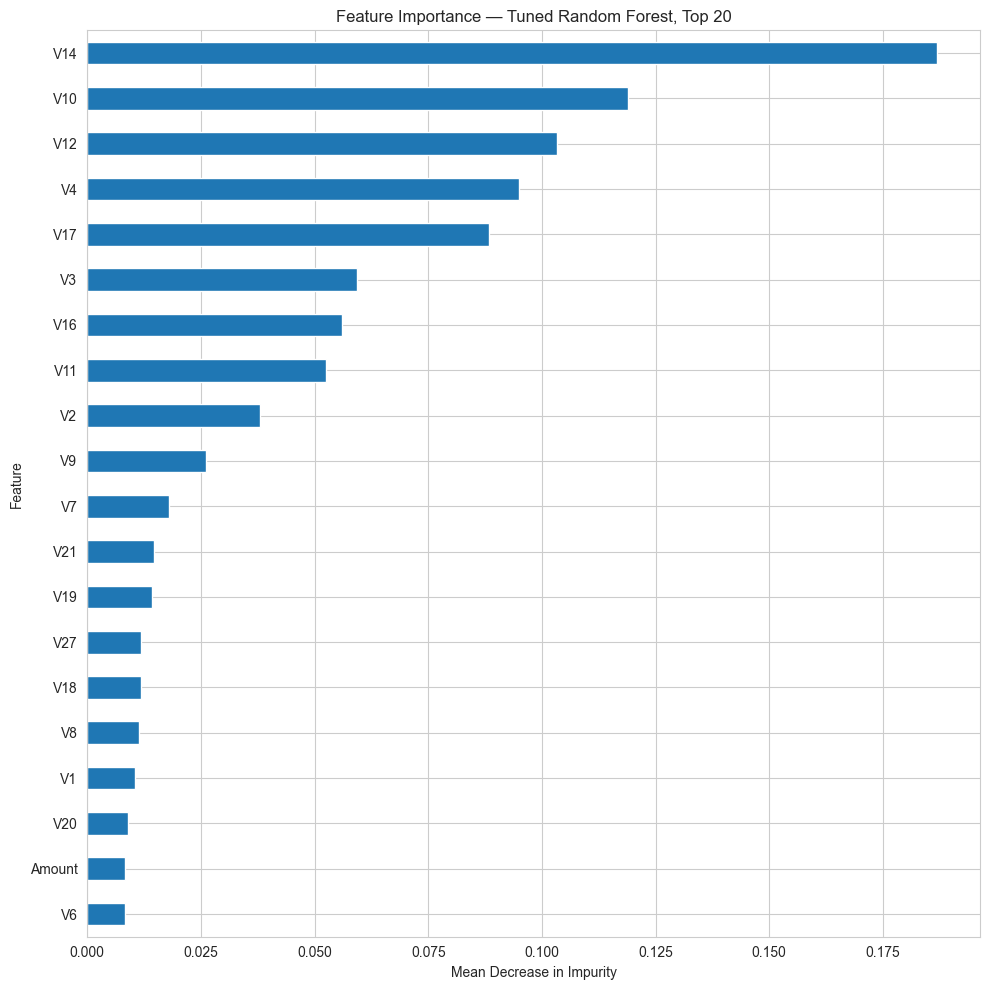

Top 10 Important Features
-------------------------


V14    0.1870
V10    0.1190
V12    0.1034
V4     0.0950
V17    0.0883
V3     0.0594
V16    0.0560
V11    0.0526
V2     0.0381
V9     0.0261
dtype: float64

In [47]:
# Feature importance from tuned Random Forest

importances = pd.Series(
    rf_tuned_model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 10))

importances.tail(20).plot(kind="barh")

plt.title("Feature Importance — Tuned Random Forest, Top 20")
plt.xlabel("Mean Decrease in Impurity")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 10 Important Features")
print("-------------------------")
display(importances.tail(10).sort_values(ascending=False).round(4))

### Feature Importance Interpretation

The tuned Random Forest model identified several PCA-transformed features as highly important for fraud detection.

Features such as `V14`, `V4`, `V10`, `V12`, and `V17` appear among the most important features. This is consistent with the EDA stage, where several V-features showed stronger separation between legitimate and fraudulent transactions.

The `Amount` feature may also contribute to prediction, but the PCA-transformed features are more important overall.

Since the V-features are anonymized, their real-world meanings cannot be interpreted directly. However, their importance values still show that they are useful for machine learning-based fraud detection.

## 12. Prediction Example

We apply the tuned Random Forest model to a small sample of test transactions to demonstrate end-to-end prediction.

The sample includes both fraud and legitimate transactions. The model outputs the predicted class and the probability of fraud.

In a real fraud detection system, the probability threshold can be adjusted depending on the business cost of false positives and false negatives.

In [48]:
# Select a small sample from the test set
# 3 fraud transactions and 3 legitimate transactions

sample_fraud = X_test[y_test == 1].head(3)
sample_legit = X_test[y_test == 0].head(3)

sample = pd.concat([sample_fraud, sample_legit])

# Get actual labels
y_sample = y_test.loc[sample.index]

# Predict using tuned Random Forest model
sample_predictions = rf_tuned_model.predict(sample)
sample_probabilities = rf_tuned_model.predict_proba(sample)[:, 1]

# Create result table
prediction_example = pd.DataFrame({
    "Actual Class": y_sample.map({0: "Legitimate", 1: "Fraud"}).values,
    "Predicted Class": pd.Series(sample_predictions).map({0: "Legitimate", 1: "Fraud"}).values,
    "Fraud Probability": sample_probabilities
})

prediction_example["Fraud Probability"] = prediction_example["Fraud Probability"].round(4)

display(prediction_example)

,Actual Class,Predicted Class,Fraud Probability
0,Fraud,Fraud,0.8596
1,Fraud,Fraud,0.8296
2,Fraud,Legitimate,0.1297
3,Legitimate,Legitimate,0.0000
4,Legitimate,Legitimate,0.0000
5,Legitimate,Legitimate,0.0000


### Prediction Example Interpretation

The prediction example shows how the trained model classifies individual test transactions.

The `Actual Class` column shows the real label from the dataset, while the `Predicted Class` column shows the model prediction. The `Fraud Probability` column shows how confident the model is that the transaction is fraudulent.

A probability close to 1 means the model strongly believes the transaction is fraud. A probability close to 0 means the model strongly believes the transaction is legitimate.

This example demonstrates how the trained model can be used for individual transaction prediction.

## 13. Final Summary

## Model Performance Overview

The model comparison table above summarizes the performance of all trained models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

The models used in this project are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Naive Bayes
5. Tuned Random Forest

The final model selection should not be based on accuracy alone because this dataset is highly imbalanced.

---

## Why Accuracy Is Misleading Here

The dataset contains a very small number of fraud transactions compared to legitimate transactions.

After data cleaning:

- Legitimate transactions: 283,253
- Fraud transactions: 473
- Fraud rate: approximately 0.1667%

Because of this imbalance, a model can get very high accuracy by predicting most transactions as legitimate. However, such a model may fail to detect actual fraud cases.

For fraud detection, the more important evaluation metrics are:

- **Recall**: How many actual fraud transactions were correctly detected.
- **Precision**: Out of all transactions predicted as fraud, how many were actually fraud.
- **F1-score**: A balanced score between Precision and Recall.
- **ROC-AUC**: Measures how well the model separates fraud and legitimate transactions.
- **Confusion Matrix**: Shows true positives, false positives, true negatives, and false negatives.

---

## Key Takeaways

1. The dataset was highly imbalanced, so accuracy alone was not suitable for model evaluation.
2. Logistic Regression was used as a baseline model with `class_weight="balanced"`.
3. Decision Tree was able to learn non-linear patterns but can overfit if not controlled.
4. Random Forest gave strong performance by combining multiple decision trees.
5. Naive Bayes was fast and simple, but may perform weaker because it does not support class weighting.
6. Random Forest tuning was performed to improve model performance using selected hyperparameters.
7. Feature importance showed that several PCA-transformed features were useful for fraud detection.
8. The best model should be selected based mainly on F1-score, Recall, Precision, ROC-AUC, and the confusion matrix.

---

## Final Model Selection

Based on the model comparison, the final selected model is the model with the best balance between Precision, Recall, and F1-score.

For this project, the Random Forest or Tuned Random Forest model is the most suitable final model if it gives the highest or most balanced F1-score.

Random Forest is suitable because:

- It handles complex patterns better than a single Decision Tree.
- It usually gives strong Precision and F1-score.
- It reduces overfitting compared to a single tree.
- It provides feature importance values.
- It performs well on fraud detection data when class imbalance is handled.

---

## Limitations

Although the project gives good results, there are some limitations:

1. The dataset is highly imbalanced, so fraud detection remains difficult.
2. The `V1` to `V28` features are anonymized PCA features, so their real-world meaning cannot be directly explained.
3. The model was evaluated using historical data, so real-world performance may be different.
4. The default prediction threshold of 0.5 may not be ideal for a real fraud detection system.
5. In a real banking system, false positives and false negatives have different business costs.

---

## Future Improvements

This project can be improved by:

1. Trying resampling methods such as SMOTE or undersampling.
2. Tuning the probability threshold to balance Precision and Recall.
3. Testing more advanced models such as XGBoost or LightGBM.
4. Using cost-sensitive learning based on business risk.
5. Deploying the trained model as a simple web application or API.
6. Saving the final trained model using `joblib` or `pickle`.

---

## Final Conclusion

This project successfully completed a full machine learning workflow for credit card fraud detection.

The workflow included:

1. Exploratory Data Analysis
2. Data Cleaning
3. Feature Scaling
4. Model Training
5. Model Evaluation
6. Model Comparison
7. Hyperparameter Tuning
8. Feature Importance Analysis
9. Prediction Example

The final result shows that machine learning models can detect fraudulent transactions, but model evaluation must focus on fraud-specific metrics rather than accuracy alone.
